In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = ''

In [4]:
def read_uvb(rootdir, filename):
    
    # First read in the file, line by line
    with open(rootdir+filename) as file:
        uvb_lines = [line.rstrip() for line in file]
        
    # Next, isolate a grid of redshifts
    
    # Specify default delimiter
    # Necessary for processing later
    
    # HM05 and 12
    if filename == 'hm05_galaxy.ascii' or filename == 'hm12_galaxy.ascii':
        dm = '  '
    # FG20
    else:
        dm = ' '

    # Read all lines relevant to redshift
    uvb_lines_z_grid = uvb_lines[uvb_lines.index('# z_grid')+1: uvb_lines.index('# wav_grid')]
    # Split apart the strings
    uvb_lines_z_grid_split = [z_grid_str.strip().replace(dm,',').split(',') for z_grid_str in uvb_lines_z_grid]
    # Flatten the list
    uvb_lines_z_grid_flat = [item for sublist in uvb_lines_z_grid_split for item in sublist]
    # Numpy-fy and flatten
    uvb_z_grid = np.array(uvb_lines_z_grid_flat, dtype='float')
   
    # Next, get the grid of wavelengths
    
    # Read in all lines relevant to wavelength
    uvb_lines_wav_grid = uvb_lines[uvb_lines.index('# wav_grid')+1: uvb_lines.index('# f_nu_list')]
    # Split apart the strings
    uvb_lines_wav_grid_split = [wav_grid_str.strip().replace(dm, ',').split(',') for wav_grid_str in uvb_lines_wav_grid]
    # Flatten the list
    uvb_lines_wav_grid_flat = [item for sublist in uvb_lines_wav_grid_split for item in sublist]
    #print(uvb_lines_wav_grid_split)
    # Numpy-fy and flatten
    uvb_wav_grid = np.array(uvb_lines_wav_grid_flat, dtype='float').flatten()    
    
    # Read in the list of f_nu and reshape
    uvb_lines_J_nu_list = uvb_lines[uvb_lines.index('# f_nu_list')+1:]
    # Split apart the strings
    uvb_lines_J_nu_split = [J_nu_str.strip().replace(dm, ',').split(',') for J_nu_str in uvb_lines_J_nu_list]
    # Flatten and reshape
    uvb_J_nu_grid = np.array([item for sublist in uvb_lines_J_nu_split for item in sublist], dtype='float').reshape((len(uvb_z_grid), len(uvb_wav_grid))) 
    
    return uvb_z_grid, uvb_wav_grid, uvb_J_nu_grid

In [5]:
# Isolate data form HM05, HM12, FG20
hm05_z_grid, hm05_wav_grid, hm05_J_nu_grid = read_uvb(rootdir, 'hm05_galaxy.ascii')
hm12_z_grid, hm12_wav_grid, hm12_J_nu_grid = read_uvb(rootdir, 'hm12_galaxy.ascii')
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb(rootdir, 'fg20_galaxy.ascii')

In [6]:
from astropy import constants
from astropy import units

def wav_2_ryd(wav):
    # Wavelength in Angstrom, convert to m
    # Astropy has Ryd in inverse meters
    return 1/(wav*1e-10*constants.Ryd.value)

In [7]:
# Convert wavelength grids to energies
hm05_ryd_grid = wav_2_ryd(hm05_wav_grid)
hm12_ryd_grid = wav_2_ryd(hm12_wav_grid)
fg20_ryd_grid = wav_2_ryd(fg20_wav_grid)

In [8]:
def fetch_sed(z, uvb_z_grid, uvb_J_nu_grid):
    
    # First find the redshift closest to the desired one 
    # Search the redshift grid for the same
    
    idx = np.argmin(np.abs(uvb_z_grid-z))
    
    # Isolate f_nu
    
    uvb_J_nu = uvb_J_nu_grid[idx]
    
    return uvb_J_nu

In [36]:
z_test = 0.68

In [37]:
hm05_J_nu_test = fetch_sed(z_test, hm05_z_grid, hm05_J_nu_grid)
hm12_J_nu_test = fetch_sed(z_test, hm12_z_grid, hm12_J_nu_grid)
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

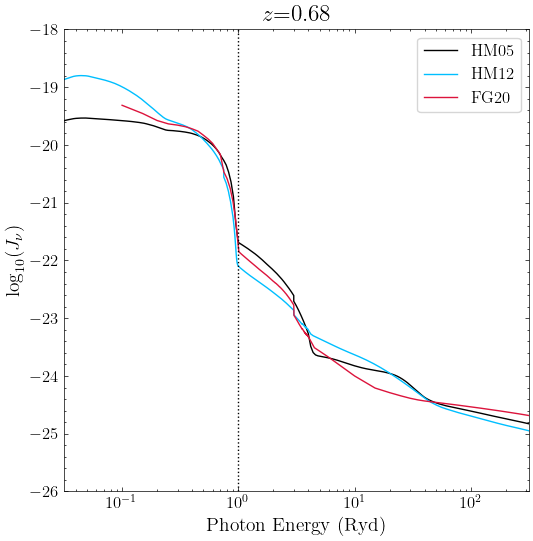

In [38]:
fig, ax = plt.subplots(1, figsize=(6,6))

ax.plot(hm05_ryd_grid, np.log10(hm05_J_nu_test), label='HM05')
ax.plot(hm12_ryd_grid, np.log10(hm12_J_nu_test), label='HM12')
ax.plot(fg20_ryd_grid, np.log10(fg20_J_nu_test), label='FG20')

ax.set_xscale('log')
ax.set_ylim(-26,-18)
ax.set_xlim(10**-1.5, 10**2.5)

ax.set_title('$z$={}'.format(z_test))
ax.set_xlabel('Photon Energy (Ryd)')
ax.set_ylabel(r'$\log_{10}(J_\nu)$')

ax.axvline(1, linestyle=':')

ax.legend()